In [4]:
#Problem-1
import pandas as pd
import numpy as np

# Load the dataset
data = pd.read_csv("diabetes_.csv")

# Display first 5 rows
print("First 5 rows of dataset:\n", data.head())

# Check data types and summary
print("\nData types:\n", data.dtypes)
print("\nSummary statistics:\n", data.describe())

# Check missing values
print("\nMissing values:\n", data.isnull().sum())
# Calculate percentage of missing values
missing_info = data.isnull().sum() / len(data) * 100

# Handle missing values
for column in data.columns:
    if missing_info[column] > 10:  # More than 10% missing → fill with mean
        data[column].fillna(data[column].mean(), inplace=True)
    else:  # Less than 10% missing → drop rows
        data.dropna(subset=[column], inplace=True)

print("\nMissing values after processing:\n", data.isnull().sum())
# Separate features (X) and target (y)
X = data.drop(columns=['Outcome']).values
y = data['Outcome'].values

# Custom train-test split
def train_test_split_scratch(X, y, test_size=0.3, random_seed=42):
    np.random.seed(random_seed)
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)
    test_split_size = int(len(X) * test_size)
    test_indices = indices[:test_split_size]
    train_indices = indices[test_split_size:]
    return X[train_indices], X[test_indices], y[train_indices], y[test_indices]

X_train, X_test, y_train, y_test = train_test_split_scratch(X, y, test_size=0.3)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
def euclidean_distance(point1, point2):
    if point1.shape != point2.shape:
        raise ValueError("Points must have same dimensions")
    return np.sqrt(np.sum((point1 - point2) ** 2))#USED THE FORMULA:WHOLE SQUARE{𝑑=∑(𝑥𝑖−𝑦𝑖)2}
def knn_predict_single(query, X_train, y_train, k=3):
    distances = [euclidean_distance(query, x) for x in X_train]
    sorted_indices = np.argsort(distances)
    nearest_indices = sorted_indices[:k]
    nearest_labels = y_train[nearest_indices]
    prediction = np.bincount(nearest_labels).argmax()
    return prediction

def knn_predict(X_test, X_train, y_train, k=3):
    return np.array([knn_predict_single(x, X_train, y_train, k) for x in X_test])
def compute_accuracy(y_true, y_pred):
    correct = np.sum(y_true == y_pred)
    return (correct / len(y_true)) * 100

predictions = knn_predict(X_test, X_train, y_train, k=3)
accuracy = compute_accuracy(y_test, predictions)
print(f"Accuracy: {accuracy:.2f}%")



First 5 rows of dataset:
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Data types:
 Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age        

In [5]:
#Problem-2
# Scale features (min-max normalization)
X_scaled = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))

# Split scaled data
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split_scratch(X_scaled, y)

# Run KNN on scaled data
predictions_s = knn_predict(X_test_s, X_train_s, y_train_s, k=3)
accuracy_s = compute_accuracy(y_test_s, predictions_s)

print(f"Accuracy (original): {accuracy:.2f}%")
print(f"Accuracy (scaled): {accuracy_s:.2f}%")



Accuracy (original): 67.39%
Accuracy (scaled): 69.13%


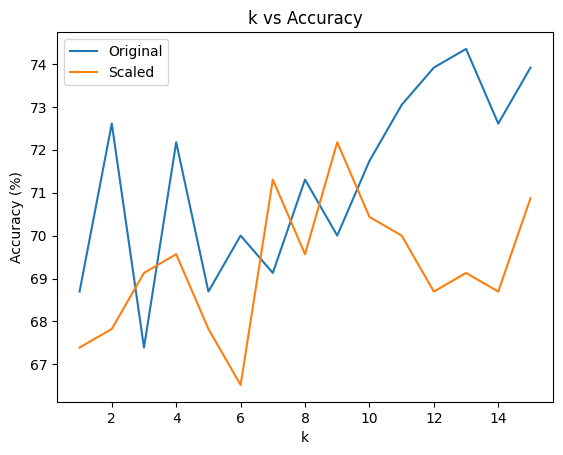

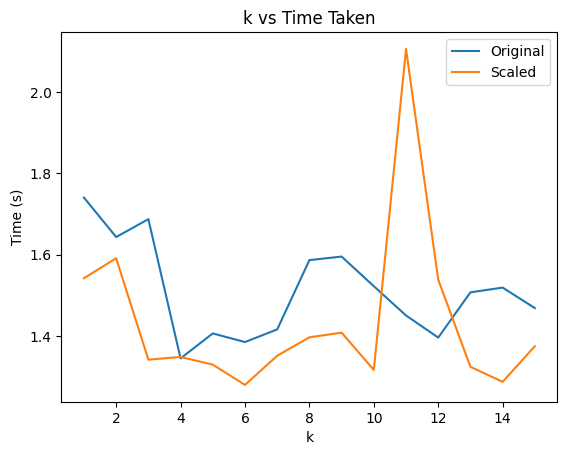

In [6]:
#Problem-3
import time
import matplotlib.pyplot as plt

def experiment_knn_k_values(X_train, y_train, X_test, y_test, k_values):
    accuracies, times = {}, {}
    for k in k_values:
        start = time.time()
        preds = knn_predict(X_test, X_train, y_train, k)
        end = time.time()
        accuracies[k] = compute_accuracy(y_test, preds)
        times[k] = end - start
    return accuracies, times

k_values = range(1, 16)
acc_orig, time_orig = experiment_knn_k_values(X_train, y_train, X_test, y_test, k_values)
acc_scaled, time_scaled = experiment_knn_k_values(X_train_s, y_train_s, X_test_s, y_test_s, k_values)

# Plot Accuracy
plt.plot(k_values, list(acc_orig.values()), label="Original")
plt.plot(k_values, list(acc_scaled.values()), label="Scaled")
plt.xlabel("k")
plt.ylabel("Accuracy (%)")
plt.title("k vs Accuracy")
plt.legend()
plt.show()

# Plot Time
plt.plot(k_values, list(time_orig.values()), label="Original")
plt.plot(k_values, list(time_scaled.values()), label="Scaled")
plt.xlabel("k")
plt.ylabel("Time (s)")
plt.title("k vs Time Taken")
plt.legend()
plt.show()
